In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.79MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.53MB/s]


Number of Training images: 60000, and Testing images: 10000


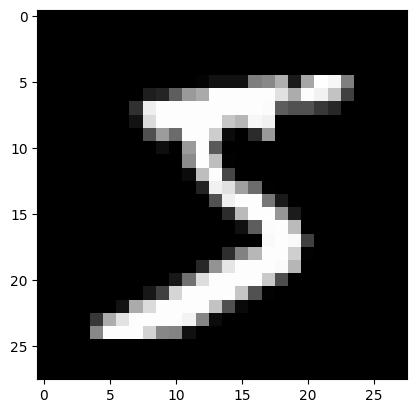

The image is of 5


In [ ]:
# Loading MNIST dataset:

train_data = datasets.MNIST(root = './data', train = True, transform = transforms.ToTensor(), download=True)
test_data = datasets.MNIST(root = './data', train = False, transform = transforms.ToTensor(), download=True)

print(f'Number of Training images: {len(train_data)}, and Testing images: {len(test_data)}')

plt.imshow(train_data[0][0].squeeze(), cmap = 'gray')
plt.show()
print('The image is of', train_data[0][1])

In [ ]:
# Creating Train and Test Loader

BATCH_SIZE = 128

train_loader = DataLoader(train_data, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_data, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
# Class that defines AutoEncoders

class AutoEncoder(nn.Module):

  def __init__(self, hidden_dim = 256, latent_dim = 32):     # Architecture is written in the constructor
    super().__init__()

    # Encoder
    self.encoder = nn.Sequential(nn.Linear(784, hidden_dim),
                                 nn.ReLU(),
                                 nn.Linear(hidden_dim, latent_dim),
                                 nn.ReLU()
                                 )
    # Decoder
    self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden_dim),
                                 nn.ReLU(),
                                 nn.Linear(hidden_dim, 784),
                                 nn.Sigmoid()
                                 )


  # Forward Pass
  def forward(self, x):                                   # Input passes throgh the Architecture in the forward pass
    z = self.encoder(x)
    x_reconstructed = self.decoder(z)
    return x_reconstructed

In [ ]:
# Defining Model, Loss, & Optimizer

model = AutoEncoder()

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [ ]:
# Training

epoch = 5

model.train()

for epoch in range(epoch):

  total_loss = 0

  for x, _ in train_loader:

    x = x.view(-1, 784)     # Batch looks like [128, 1, 28, 28], now there are 60k images, so the last batch formed will not be of size 128, it will have 96 images. Hence we did not write .view(128, 784), as it might throw error for the last batch (where instead 128 only 96 images are left).
                            # [24] --> .view(3, 2, -1) automatically calculates the value for position where -1 is written, so [24] = [3, 2, 4]. You can see other places where there isin't -1 is fixed but at place where it has -1 pytorch automatically calculates what should be there.

    optimizer.zero_grad()

    x_recon = model.forward(x)

    loss = criterion(x_recon, x)    # loss --> loss of the current batch
    loss.backward()
    optimizer.step()

    batch_loss = loss.item()
    total_loss += loss.item()       # loss of all the batches combined

  epoch_loss = total_loss / len(train_loader)   # Average of Total loss of all batches = epoch_loss

  print(f'Epoch{(epoch + 1)}: Loss: {epoch_loss: .6f}')


Epoch1: Loss:  0.043427
Epoch2: Loss:  0.018765
Epoch3: Loss:  0.014784
Epoch4: Loss:  0.013328
Epoch5: Loss:  0.012451


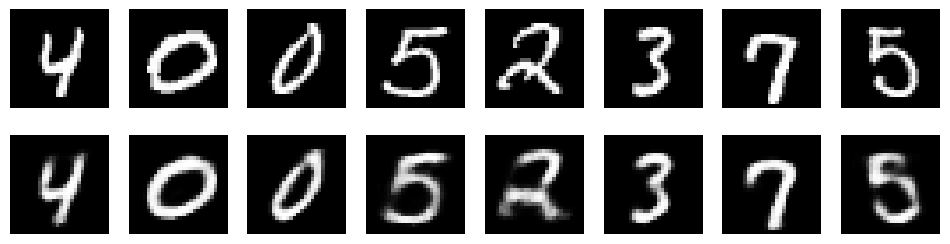

In [ ]:
# Plotting Original vs Reconstructed images from Testing data

model.eval()

with torch.no_grad():

  x, _ = next(iter(test_loader))
  x = x.view(-1, 784)
  x_recon = model.forward(x)

  n = 8                                           # n --> Number of images to plot
  plt.figure(figsize = (12, 3))

  for i in range(n):

    # Original image
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28, 28), cmap = 'gray')
    plt.axis('off')

    # Reconstructed image
    plt.subplot(2, n, i+1+n)
    plt.imshow(x_recon[i].view(28, 28), cmap = 'gray')
    plt.axis('off')

  plt.show()